<a href="https://colab.research.google.com/github/naidhruvraj/Real-time-body-size-estimator/blob/main/sem6_body_meauremenet_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#  1....imporing necessary libraries
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.2/757.2 kB 10.9 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.19.3-py3-none-manylinux1_x86_64.whl (166.0 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-man

In [ ]:
import cv2
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [ ]:
#user defined function for imshow
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

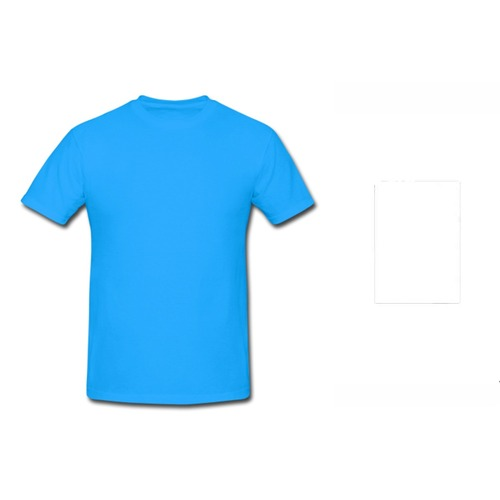

(500, 500)

In [ ]:
#   2....getting image input from user

img1=cv2.imread("/content/input_image.jpg")
cv2_imshow(img1)
img1.shape[:2]

In [ ]:
import shutil
import os

# Specify the path to the folder you want to check
folder_path = '/content/runs'

# Check if the folder exists
if os.path.isdir(folder_path):
  folder_path = '/content/runs'
  shutil.rmtree(folder_path)
# Path to the folder you want to delete
# Delete the folder


In [ ]:
#    3....importing of trained custom_model for object detection
from ultralytics import YOLO
model=YOLO('/content/best_final_may.pt')

In [ ]:
#    4....shirt and paper detection using the trained model

model.predict(img1,imgsz=640,conf=0.3,save=True,save_crop=True)


0: 640x640 1 paper, 1 tshirt, 2335.6ms
Speed: 18.0ms preprocess, 2335.6ms inference, 2982.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'paper', 1: 'tshirt'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
      

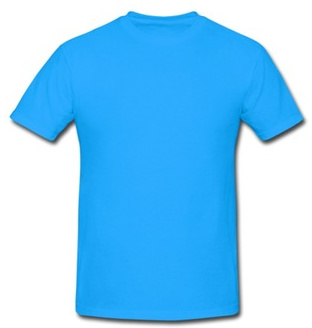

In [ ]:
#    5.1....detected shirt image

img=cv2.imread("/content/runs/detect/predict/crops/tshirt/image0.jpg")
cv2_imshow(img)

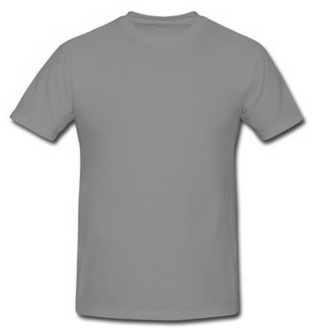

(328, 312)


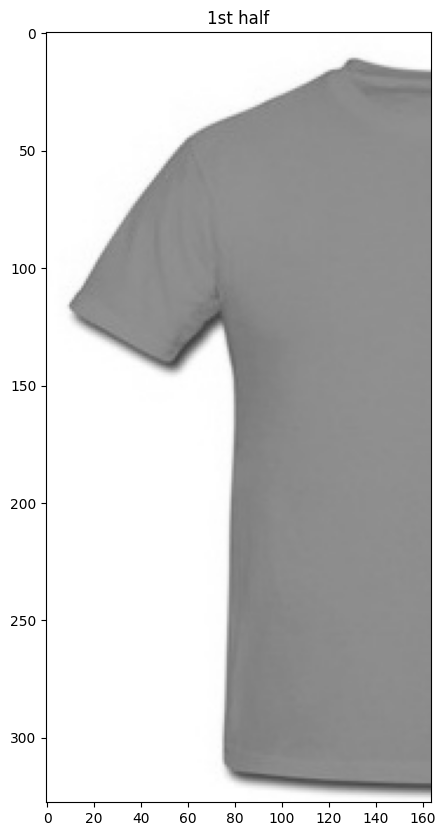

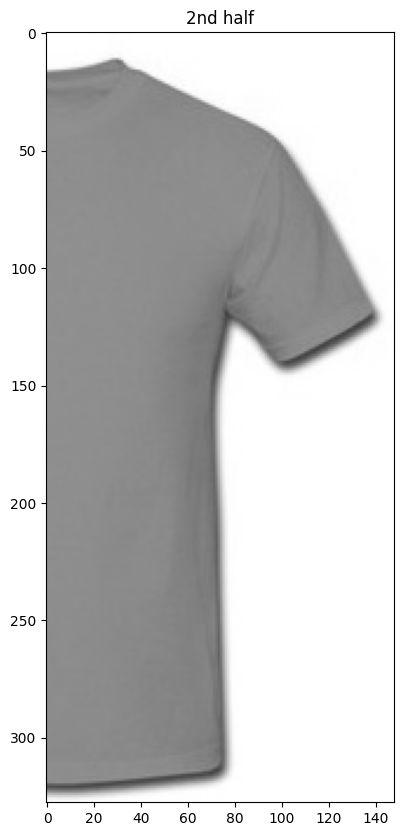

In [ ]:
#    5.2....grayscale conversion and croping of the image

grey=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
cv2_imshow(grey)
print(grey.shape[:2])
width=int(img.shape[0]/2)
crop1=grey[:,:width]
imshow("1st half",crop1)
crop2=grey[:,width:]
imshow("2nd half",crop2)

(328, 164)
[[125, 74], [116, 10], [12, 129], [315, 80], [141, 52], [45, 60]]
{1: [10, 116], 2: [52, 141], 3: [60, 45], 4: [74, 125], 5: [80, 315], 6: [129, 12]}


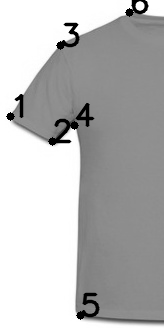

In [ ]:
#     5.3....Find left corners using Shi-Tomasi corner detection

corners = cv2.goodFeaturesToTrack(crop1, maxCorners=6, qualityLevel=0.01, minDistance=23)
color = (0, 0, 255)

points1=[]
fontScale = 1
thickness = 2
for corner in corners:
    x, y = corner.ravel()
    points1.append([int(y),int(x)])
print(crop1.shape[:2])
print(points1)
dictleft={}
k=1
for i in range(crop1.shape[1]):
    for j in range(crop1.shape[0]):
      if [j,i] in points1:
        dictleft[k]=[i,j]
        cv2.circle(crop1, (int(i), int(j)), 4, color, -1)
        cv2.putText(crop1, str(k),(int(i), int(j)), cv2.FONT_HERSHEY_SIMPLEX,fontScale, color, thickness, cv2.LINE_AA)
        k+=1
print(dictleft)

# Display the image

cv2_imshow(crop1)
cv2.waitKey(0)
cv2.destroyAllWindows()

(328, 148)
[[120, 138], [126, 80], [12, 31], [140, 100], [313, 74], [46, 98]]
{1: [302, 120], 2: [264, 140], 3: [262, 46], 4: [244, 126], 5: [238, 313], 6: [195, 12]}


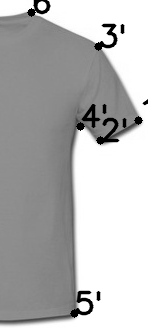

In [ ]:
#      5.4....Find right corners using Shi-Tomasi corner detection

corners2 = cv2.goodFeaturesToTrack(crop2, maxCorners=6, qualityLevel=0.01, minDistance=23)
color = (0, 0, 255)

points2=[]
fontScale = 1
thickness = 2
z=1
for corner in corners2:
    x, y = corner.ravel()
    points2.append([int(y),int(x)])
    z+=1
print(crop2.shape[:2])
print(points2)
dictright={}
l=1
for i in range(crop2.shape[1],-1,-1):
    for j in range(crop2.shape[0]):
      if [j,i] in points2:
        dictright[l]=[crop1.shape[1]+i,j]
        cv2.circle(crop2, (int(i), int(j)), 4, color, -1)
        cv2.putText(crop2, str(l)+"'",(int(i), int(j)), cv2.FONT_HERSHEY_SIMPLEX,fontScale, color, thickness, cv2.LINE_AA)
        l+=1
print(dictright)

# Display the image

cv2_imshow(crop2)
cv2.waitKey(0)
cv2.destroyAllWindows()

(328, 312)


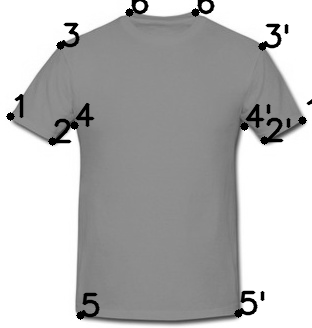

In [ ]:
#       5.5....merging of the cropped images for final result

print(grey.shape[:2])
black=np.ones((grey.shape[0],grey.shape[1]),dtype="uint8")
black[:,:crop1.shape[1]]=crop1
black[:,crop1.shape[1]:]=crop2
cv2_imshow(black)

In [ ]:
#        6....OBTAINING FINAL MEASUREMENTS IN PIXELS

measurement={}
measurement["collar"]=math.dist(dictleft[6],dictright[6])
measurement["shoulder"]=math.dist(dictleft[3],dictright[3])
measurement["chest"]=math.dist(dictleft[4],dictright[4])
measurement["sleeve_length"]=math.dist(dictleft[3],dictleft[1])
measurement["waist"]=math.dist(dictleft[5],dictright[5])
measurement["length"]=math.dist(dictleft[3],dictright[5])
print(measurement)

{'collar': 66.0, 'shoulder': 202.00247523235947, 'chest': 170.00294115102832, 'sleeve_length': 86.83893136145792, 'waist': 158.01265772082945, 'length': 321.72659200010185}


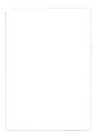

(137, 96)

In [ ]:
#          7.1....obtaining measurement of reference object(paper) in pixels

paper=cv2.imread("/content/runs/detect/predict/crops/paper/image0.jpg")
gpaper=cv2.cvtColor(paper,cv2.COLOR_BGR2GRAY)
cv2_imshow(gpaper)
paper.shape[:2]

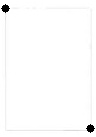

In [ ]:
#            7.2....Find corners using Shi-Tomasi corner detection for the paper
c = cv2.goodFeaturesToTrack(gpaper, maxCorners=4, qualityLevel=0.01, minDistance=23)
color = (0, 255, 0)
xmin=paper.shape[0]
ymin=paper.shape[1]
xmax=0
ymax=0
l=[]
j=1
fontScale = 1
thickness = 2
# Draw corners on the original image
for corner in c:
    x, y = corner.ravel()
    xmin=min(xmin,x)
    xmax=max(xmax,x)
    ymin=min(ymin,y)
    ymax=max(ymax,y)
    #cv2.circle(gpaper, (int(x), int(y)), 4, color, -1)
    #cv2.putText(gpaper, str(j),(int(x), int(y)), cv2.FONT_HERSHEY_SIMPLEX,fontScale, color, thickness, cv2.LINE_AA)
    j+=1
cv2.circle(gpaper,(int(xmin),int(ymin)),4,color,-1)
cv2.circle(gpaper,(int(xmax),int(ymax)),4,color,-1)
# Display the image
cv2_imshow(gpaper)
cv2.waitKey(0)
cv2.destroyAllWindows()

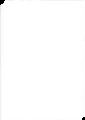

(120, 85)


In [ ]:
#        7.3....obtaining the fianl pixel size of the image
crop_paper=gpaper[int(ymin):int(ymax),int(xmin):int(xmax)]
cv2_imshow(crop_paper)
print(crop_paper.shape[:2])

In [ ]:
#         7.4   method 1:converting pixels to cm to find the multiplicative ratio
ref_ratio=29.7/(crop_paper.shape[0])
print(ref_ratio)

#         method 2:scaling_factor
s_f=crop_paper.shape[0]/29.7
print(s_f)

0.2475
4.040404040404041


In [ ]:
#         7.5 method 1:finding the measurements of the cloth in cm
measurement={}
measurement["collar"]=ref_ratio*math.dist(dictleft[6],dictright[6])
measurement["shoulder"]=ref_ratio*math.dist(dictleft[3],dictright[3])
measurement["chest"]=ref_ratio*math.dist(dictleft[4],dictright[4])
measurement["sleeve_length"]=ref_ratio*math.dist(dictleft[1],dictleft[3])
measurement["waist"]=ref_ratio*math.dist(dictleft[5],dictright[5])
measurement["length"]=ref_ratio*math.dist(dictleft[3],dictleft[5])
print(measurement)

#          method 2:measurement using scaling_factor
measurement2={}
measurement2["collar"]=math.dist(dictleft[6],dictright[6])/s_f
measurement2["shoulder"]=math.dist(dictleft[3],dictright[3])/s_f
measurement2["chest"]=math.dist(dictleft[4],dictright[4])/s_f
measurement2["sleeve_length"]=math.dist(dictleft[3],dictleft[1])/s_f
measurement2["waist"]=math.dist(dictleft[5],dictright[5])/s_f
measurement2["length"]=math.dist(dictleft[3],dictleft[5])/s_f
print(measurement2)


{'collar': 16.335, 'shoulder': 49.99561262000897, 'chest': 42.07572793487951, 'sleeve_length': 21.492635511960835, 'waist': 39.10813278590529, 'length': 67.00808253487038}
{'collar': 16.334999999999997, 'shoulder': 49.99561262000896, 'chest': 42.07572793487951, 'sleeve_length': 21.492635511960835, 'waist': 39.10813278590528, 'length': 67.00808253487037}


In [ ]:
# ....................RESULT
print(f" Collar size = {measurement['collar']:.2f} cm\n Shoulder size = {measurement['shoulder']:.2f} cm\n Chest size = {measurement['chest']:.2f} cm\n Sleeve_length = {measurement['sleeve_length']:.2f} cm\n waist size = {measurement['waist']:.2f} cm\n heigth = {measurement['length']:.2f} cm\n")

 Collar size = 14.59 cm
 Shoulder size = 44.65 cm
 Chest size = 37.58 cm
 Sleeve_length = 19.20 cm
 waist size = 34.93 cm
 heigth = 71.12 cm

